## Boundray point VAE

In [1]:
import numpy as np
import torch
from torch import optim
from torch.utils.data import DataLoader, TensorDataset

from models.BPResVAE import BPResVAE
from utils.load_bp import load_from_dir
from copy import deepcopy
from matplotlib import pyplot as plt
from utils.generate import generate_contour, reconstruct_contour
from hbs import boundary
from utils.visualize import contour_to_binary, contour_to_scatter, make_grid
import random

In [2]:
img_dir = "data/img/BW bird"

bp_np = load_from_dir(img_dir, 100, 25)
print(bp_np.shape)

Loading BW1.jpg
Loading BW10.jpg
Loading BW11.jpg
Loading BW12.jpg
Loading BW13.jpg
Loading BW14.jpg
Loading BW15.jpg
Loading BW16.jpg
Loading BW17.jpg
Loading BW18.jpg
Loading BW19.jpg
Loading BW2.jpg
Loading BW20.jpg
Loading BW3.jpg
Loading BW4.jpg
Loading BW5.jpg
Loading BW6.jpg
Loading BW7.jpg
Loading BW8.jpg
Loading BW9.jpg
(20, 100, 2)


In [3]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MAT_PATH = "data/preprocessed.theta.mat"
MODEL_SAVE_PATH = "checkpoints/ResVAE.pth"
SEED = 717

INPUT_DIM = 200  # Adjusted input dimension to match your complex data
H_DIM = 1000
Z_DIM = 2
H_LAYERS = [2, 2, 2]

NUM_EPOCHS = 20000
BATCH_SIZE = 64  # Adjusted batch size
LR_RATE = 2e-4  # smaller learning rate
KL_RATE = 0.7

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [4]:
bp_tensor = torch.tensor(bp_np).to(dtype=torch.float64)

train_data = TensorDataset(bp_tensor)
train_loader = DataLoader(
    dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True
)

## Init model
model = BPResVAE(
    input_dim=INPUT_DIM,
    hidden_dim=H_DIM,
    hidden_layers=H_LAYERS,
    latent_dim=Z_DIM,
    device=DEVICE,
)
model.to(dtype=torch.float64)
# model.initial()
model.load_state_dict(torch.load("checkpoints/BPResVAE.pth", weights_only=True))

## Load model
# model = torch.load('VAE_theta+bias1.pth')

optimizer = optim.Adam(
    model.parameters(), lr=LR_RATE, weight_decay=1e-5, betas=(0.5, 0.999)
)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10000], gamma=0.5)

# model.to(DEVICE)

loader_size = len(train_loader)
loss_list_dict = {}
best_loss = 1e9

In [ ]:
model.train()

# optimizer = optim.Adam(
#     model.parameters(), lr=1e-5, weight_decay=1e-5, betas=(0.5, 0.999)
# )
# best_loss = 1e9
# NUM_EPOCHS = 1000

for epoch in range(NUM_EPOCHS):
    for i, [input_data] in enumerate(train_loader):
        input_data = input_data.to(DEVICE, dtype=torch.float64).view(
            input_data.shape[0], INPUT_DIM
        )
        x_reconstructed, mu, logvar = model(input_data)

        # Compute loss
        # kl_rate = get_kl_rate(epoch)
        kl_rate = KL_RATE
        loss_dict = model.loss(x_reconstructed, input_data, mu, logvar, kl_rate)

        # Backprop
        optimizer.zero_grad()
        loss_dict["loss"].backward()
        optimizer.step()
        # scheduler.step()

        # Append losses to the lists
        for k, v in loss_dict.items():
            if k not in loss_list_dict:
                loss_list_dict[k] = np.zeros(loader_size)

            loss_list_dict[k][i] = v.item()

    if best_loss > loss_dict["loss"].item():
        best_loss = loss_dict["loss"].item()
        print(
            f"Best epoch {epoch}/{NUM_EPOCHS} | {', '.join([f'{k}: {v.mean():.4f}' for k, v in loss_list_dict.items()])}"
        )
        best_params = deepcopy(model.state_dict())
        # torch.save(model.state_dict(), MODEL_SAVE_PATH)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}/{NUM_EPOCHS} | {', '.join([f'{k}: {v.mean():.4f}' for k, v in loss_list_dict.items()])}"
        )

    # if epoch % 1000 == 0:
    #     torch.save(model, "checkpoints/ResVAE.pth")

model.load_state_dict(best_params)
torch.save(best_params, "checkpoints/BPResVAE.pth")

Best epoch 0/20000 | loss: 1.5632, recon_loss: 0.8320, kl_loss: 1.0445
Epoch 0/20000 | loss: 1.5632, recon_loss: 0.8320, kl_loss: 1.0445
Best epoch 5/20000 | loss: 1.5324, recon_loss: 0.6797, kl_loss: 1.2182
Best epoch 7/20000 | loss: 1.3811, recon_loss: 0.6389, kl_loss: 1.0603
Best epoch 27/20000 | loss: 1.2356, recon_loss: 0.5495, kl_loss: 0.9801
Best epoch 91/20000 | loss: 1.1188, recon_loss: 0.5274, kl_loss: 0.8447
Epoch 100/20000 | loss: 1.7657, recon_loss: 0.8785, kl_loss: 1.2675
Epoch 200/20000 | loss: 1.5999, recon_loss: 0.8690, kl_loss: 1.0442
Epoch 300/20000 | loss: 1.6456, recon_loss: 0.9827, kl_loss: 0.9470
Epoch 400/20000 | loss: 1.7064, recon_loss: 1.1678, kl_loss: 0.7695
Epoch 500/20000 | loss: 1.6946, recon_loss: 0.9400, kl_loss: 1.0779
Epoch 600/20000 | loss: 2.0220, recon_loss: 1.4690, kl_loss: 0.7900
Epoch 700/20000 | loss: 1.6897, recon_loss: 0.9209, kl_loss: 1.0982
Epoch 800/20000 | loss: 1.6521, recon_loss: 0.9188, kl_loss: 1.0477
Epoch 900/20000 | loss: 1.4577, r

Generate Data

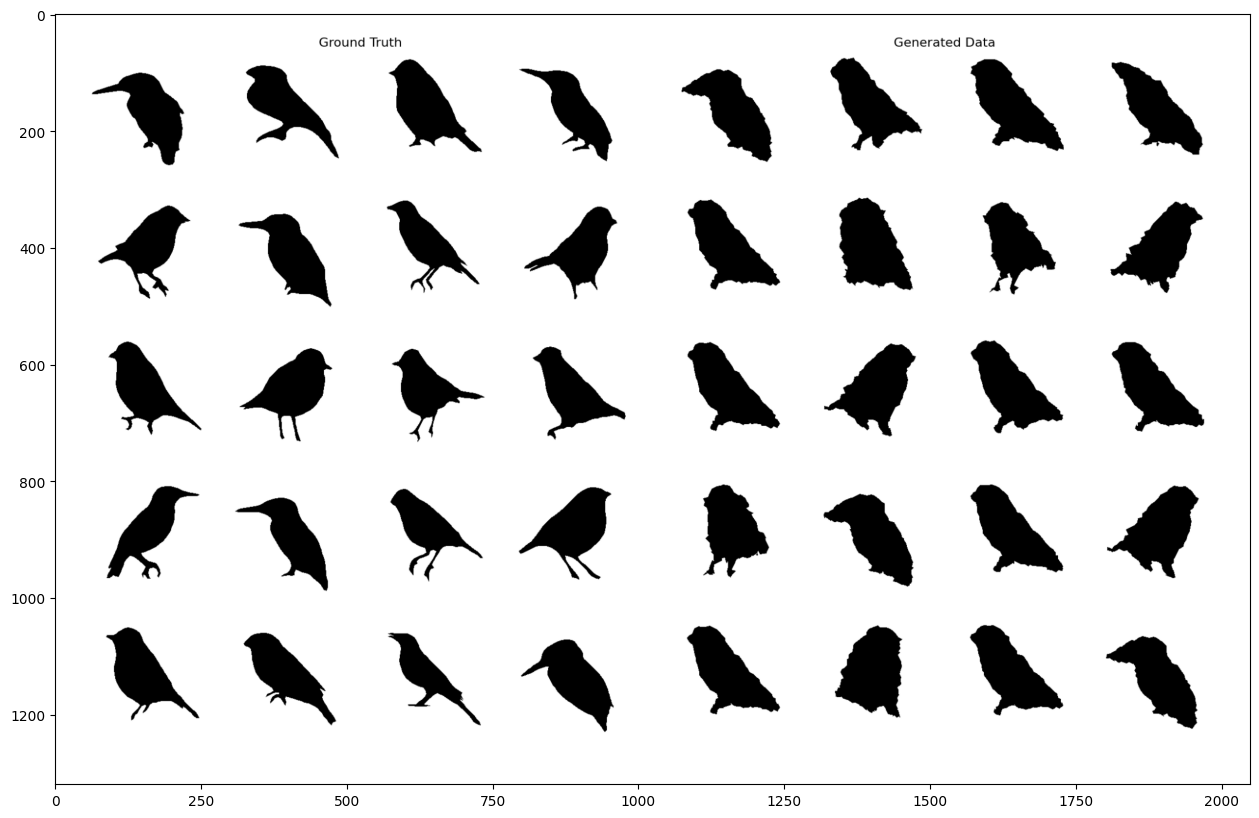

In [ ]:
n = bp_tensor.shape[0]
# generated_shape, _ = generate_data(model, num=n, k=2)
generated_contour, _, _ = model(
    bp_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM)
)
generated_contour = generated_contour.cpu().detach()
generated_contour = model.reconstruct(generated_contour).numpy()

ground_truth_contour = bp_tensor.cpu().numpy()

generated_images = [
    contour_to_binary(shape, image_size=256, rate=0.65) for shape in generated_contour
]
ground_truth_images = [
    contour_to_binary(shape, image_size=256, rate=0.65) for shape in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth")
generated_grid = make_grid(generated_images, rows=5, title="Generated Data")
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1)
fig = plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)


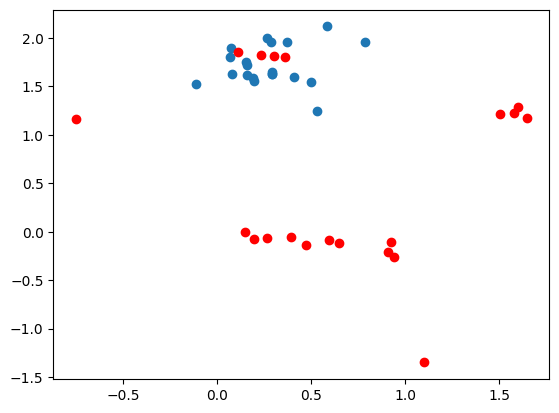

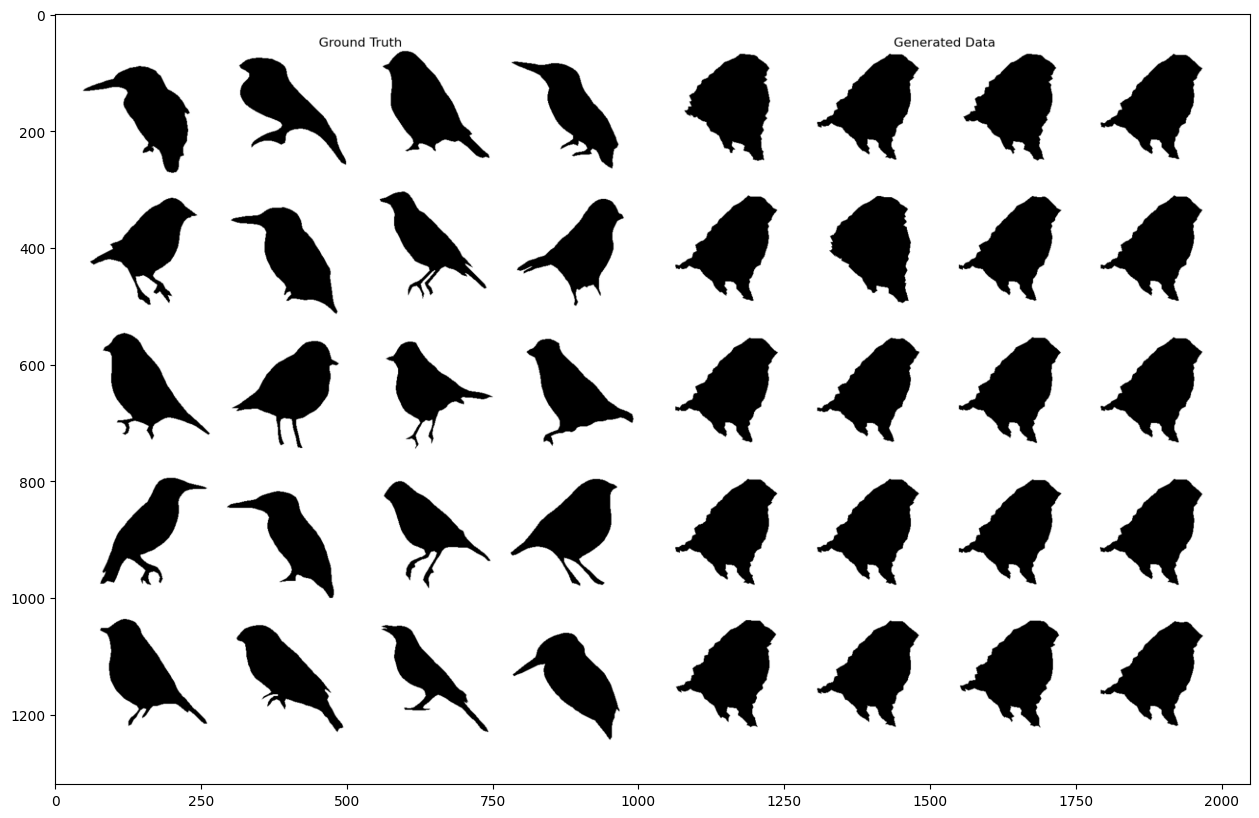

In [ ]:
from utils.generate import generate_data

num = 4
var = 0.2
mu, log_var = model.encode(bp_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM))
z0 = mu + log_var.exp().sqrt()
mu_vals = torch.repeat_interleave(z0[num].view(1, -1), n, dim=0)
generated_contour, z = generate_data(
    model, num=n, mu_vals=mu_vals, k=var
)
generated_contour = generated_contour.detach().cpu().numpy()

z = z.cpu().detach().numpy()
z0 = z0.cpu().detach().numpy()
plt.scatter(z[:, 0], z[:, 1])
plt.scatter(z0[:, 0], z0[:, 1], color="r")
plt.show()


generated_images = [contour_to_binary(shape, image_size=256) for shape in generated_contour]
ground_truth_images = [contour_to_binary(shape, image_size=256) for shape in ground_truth_contour]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title='Ground Truth')
generated_grid = make_grid(generated_images, rows=5, title='Generated Data')
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1)
fig = plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)
plt.show()